Notebook for generating plots after benching french STT models

In [8]:
import os
import json
import pandas as pd
import numpy as np

from asr_benchmark.visualization.plots import prepare_data, plot_violin_df, plot_wer_df, plot_bar_df
from asr_benchmark.utils.visualize import load_data

pd.set_option("future.no_silent_downcasting", True)

In [9]:
INPUT_FOLDER = "local_bench_fr_full"
OUTPUT_FOLDER = "local_plots"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
df = pd.DataFrame(load_data(INPUT_FOLDER))

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:07<00:00,  2.42s/it]


In [10]:
print(df["dataset"].unique())
df["dataset"] = df["dataset"].replace({
    "YouTubeFr_split6": "YouTube",
    "TEDX_fr": "TEDx",
    "MLS_Facebook_french": "MLS",
    "Voxpopuli": "VoxPopuli"
})
print(df["dataset"].unique())
datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'VoxPopuli', 'TEDx', 'YouTube']
all_models = df["model"].unique()
print(all_models)
models = all_models

['CommonVoice' 'MLS_Facebook_french' 'SUMM-RE' 'TEDX_fr' 'Voxpopuli'
 'YouTubeFr_split6']
['CommonVoice' 'MLS' 'SUMM-RE' 'TEDx' 'VoxPopuli' 'YouTube']
['bofenghuang/stt-fr-fastconformer-hybrid-large'
 'nvidia/stt-fr-fastconformer-hybrid-large-pc'
 'stt-fr-fastconformer-hybrid-large-finetuned']


In [11]:
for x in datasets:
    selected_rows = df[
        ((df["device"] == "cuda"))
        & (df['dataset'] == x)
        # & (~df['process_duration'].isnull())
        & (df['model'].isin(models))
        & ((df["decoder"] == "rnnt") | (df["decoder"].isnull()))
    ]
    selected_rows = prepare_data(selected_rows, return_format="df")
    local_output_folder = os.path.join(OUTPUT_FOLDER, "model")
    os.makedirs(local_output_folder, exist_ok=True)
    selected_rows.sort_values(by="model", inplace=True, ascending=True)
    rows_dict = prepare_data(selected_rows, return_format="dict")
    plot_wer_df(rows_dict, local_output_folder, x_column="model", title=f"WER on {x}", save_fig=f"model_wer_{x}")

In [12]:
from asr_benchmark.visualization.table import df_to_wer_table_format, plot_wer_table, generate_markdown_table_with_std, prepare_model_name, reorder_wer_pivot

wer_pivot = df_to_wer_table_format(df)

In [13]:
# Assuming wer_pivot is your pivoted DataFrame (models as rows, datasets as columns)
markdown_table = generate_markdown_table_with_std(wer_pivot)
with open(os.path.join(OUTPUT_FOLDER, "wer_table.md"), "w") as f:
    f.write(markdown_table)
print(markdown_table)

| Model | CommonVoice | MLS | SUMM-RE | TEDx | VoxPopuli | YouTube |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|
| bofenghuang/stt-fr-fastconformer-hybrid-large | **8.50**     | **4.56**     | 37.10        | **10.71**    | **10.72**    | 29.77        |
| nvidia/stt-fr-fastconformer-hybrid-large-pc   | 9.91         | 6.26         | 41.79        | 17.31        | 10.77        | 28.69        |
| stt-fr-fastconformer-hybrid-large-finetuned   | 8.79         | 4.87         | **28.43**    | 11.86        | 10.94        | **19.05**    |


/mnt/c/Users/berta/Documents/Linagora/asr_benchmark/asr_benchmark/visualization/table.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fontweight = 'bold' if wer_means.index[i] == min_indices[j] else 'normal'


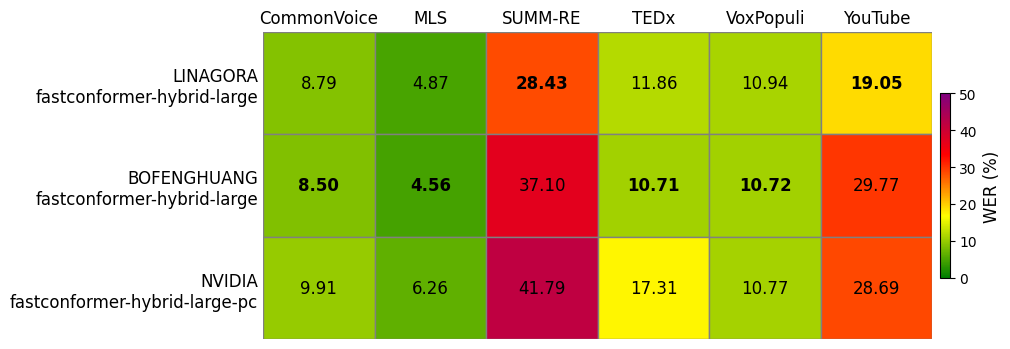

In [14]:
wer_pivot.index = [prepare_model_name(name) for name in wer_pivot.index]
wer_pivot = reorder_wer_pivot(wer_pivot)
plot_wer_table(wer_pivot, os.path.join(OUTPUT_FOLDER, "wer_table.png"))